<a href="https://colab.research.google.com/github/Saddeee/kex/blob/main/KEX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install -q tqdm keras tensorflow   # Uncomment on a fresh Colab runtime
import io, random, zipfile
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, field
from time import time
from typing import Dict, List, Tuple
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
import pickle
from tqdm import tqdm

import keras
from keras.layers import Concatenate, Dense, Embedding, Flatten, Input, Multiply
from keras.models import Model
from keras.optimizers import SGD, Adam
from keras.regularizers import l2
import os
from google.colab import drive

# 1. Mount Drive explicitly
drive.mount('/content/drive')

# 2. Define exactly where you want to save
save_dir = '/content/drive/MyDrive/'
save_path = os.path.join(save_dir, 'my_recommender_results1.pkl')

# 3. Create the directory if it somehow doesn't exist
if not os.path.exists(save_dir):
    print(f"Directory {save_dir} not found. Creating it...")
    os.makedirs(save_dir, exist_ok=True)

# 4. Check for the save file
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        results_for_num_negatives = pickle.load(f)
    print("Previous progress loaded! Ready to resume.")
else:
    results_for_num_negatives = {}
    print("No previous save found. Starting fresh.")

gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | GPUs: {gpus}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Previous progress loaded! Ready to resume.
TensorFlow 2.20.0 | GPUs: []


In [3]:
# ── Cell 1: Data Loading ──────────────────────────────────────────────────────
def load_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(response.content))

    def read_dat(name: str, cols: List[str], split) -> pd.DataFrame:
        raw = zf.read(f"ml-100k/{name}").decode("latin-1")
        return pd.read_csv(io.StringIO(raw), sep=split, engine="python", names=cols)

    users   = read_dat("u.user",   ["UserID", "Gender", "Age", "Occupation", "Zip-code"], "|")
    movies  = read_dat("u.item",  ["MovieID", "Title", "Genres"], "|")
    ratings = read_dat("u.data", ["UserID", "MovieID", "Rating", "Timestamp"], "\t")
    print(f"Loaded: {len(users)} users | {len(movies)} movies | {len(ratings)} ratings")
    return users, movies, ratings

users_df, movies_df, ratings_df = load_data()
display(users_df.head(3))
display(movies_df.head(3))
display(ratings_df.head(3))


movies =  movies_df["MovieID"].to_numpy()


Loaded: 943 users | 1682 movies | 100000 ratings


,UserID,Gender,Age,Occupation,Zip-code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067


,,,,,,,,,,,,,,,,,,,,,MovieID,Title,Genres
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%20(1995),0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(1995),0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995),0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


,UserID,MovieID,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116


In [4]:
# Rating class
class Rating:

    def __init__(self, user_id, movie_id, rating, timestamp):

        self.user_id = user_id
        self.movie_id = movie_id
        self.rating = rating
        self.timestamp = timestamp

    def __str__(self):

        return f"{self.user_id}, {self.movie_id}, {self.rating}, {self.timestamp}"
    # Required so Rating objects can live in sets (used during negative sampling)
    def __hash__(self):
        return hash((self.user_id, self.movie_id))

    def __eq__(self, other):
        return (self.user_id, self.movie_id) == (other.user_id, other.movie_id)

def _to_user_rating_dict(ratings_input) -> Dict[int, List[Rating]]:
    if isinstance(ratings_input, np.ndarray):
        d = defaultdict(list)
        for row in ratings_input:
            uid, mid, r, ts = int(row[0]), int(row[1]), float(row[2]), int(row[3])
            d[uid].append(Rating(uid, mid, r, ts))
        return d
    elif isinstance(ratings_input, dict):
        return {u: list(rs) for u, rs in ratings_input.items()}  # shallow copy
    else:
        raise TypeError(f"Unsupported input type: {type(ratings_input)}")

# -----------------------------
# Leave-One-Out Split
# -----------------------------
def leave_one_out_split(ratings_input):
    user_to_rating = _to_user_rating_dict(ratings_input)
    train: Dict[int, List[Rating]] = {}
    test:  Dict[int, Rating]       = {}
    for user, values in user_to_rating.items():
        if len(values) < 2:
            continue
        values.sort(key=lambda r: r.timestamp)
        test[user]  = values[-1]
        train[user] = values[:-1]
    return train, test

NUM_NEGATVIES = 4
# -----------------------------
# Negative Sampling (implicit training only)
# -----------------------------
def add_negative_samples(train_dict, num_movies, num_neg = NUM_NEGATVIES):
    implicit_train = {}
    all_movies_set = set(range(1, num_movies + 1))
    for user, values in train_dict.items():
        rated_movies = {r.movie_id for r in values}
        positives    = [Rating(r.user_id, r.movie_id, 1, r.timestamp) for r in values]
        negatives: List[Rating] = []
        unrated_movies = list(all_movies_set - rated_movies)
        num_neg_to_sample = len(positives)


        num_neg_to_sample = min(len(unrated_movies), num_neg_to_sample*num_neg)

        sampled_movie_ids = random.sample(unrated_movies, num_neg_to_sample)
        negatives = [Rating(user, m_id, 0, -1) for m_id in sampled_movie_ids]

        """
        while len(negatives) < len(values):
            sample = np.random.randint(1, num_movies + 1)
            if sample not in rated_movies:
                rated_movies.add(sample)   #added remvoe duplicate negatives ith random
                negatives.append(Rating(user, sample, 0, -1))
                """
        implicit_train[user] = positives + negatives
    return implicit_train

In [5]:
# Cell3 --------------Dataset Preparation-----------
#NUM_USERS_SUBSET = 10   # increase for more coverage

first_users  = ratings_df["UserID"].unique()[:]
#first_users  = ratings_df["UserID"].unique()[:NUM_USERS_SUBSET]
subset_numpy = ratings_df[ratings_df["UserID"].isin(first_users)].to_numpy()

# Three-way split via nested leave-one-out
tmp_train, test_set       = leave_one_out_split(subset_numpy)
training_split, valid_set = leave_one_out_split(tmp_train)

num_movies = int(ratings_df.MovieID.max())
max_user_id  = int(ratings_df.UserID.max())

num_users = max_user_id + 1
num_items = num_movies + 1


implicit_training_split = add_negative_samples(training_split, num_movies)

test_set_implicit  = copy.deepcopy(test_set)
valid_set_implicit = copy.deepcopy(valid_set)
for r in test_set_implicit.values():  r.rating = 1
for r in valid_set_implicit.values(): r.rating = 1


print(f"Train users : {len(training_split)}")
print(f"Val users   : {len(valid_set)}")
print(f"Test users  : {len(test_set)}")
print(f"Explicit train ratings : {sum(len(v) for v in training_split.values())}")
print(f"Implicit train ratings : {sum(len(v) for v in implicit_training_split.values())}")


Train users : 943
Val users   : 943
Test users  : 943
Explicit train ratings : 98114
Implicit train ratings : 474573


In [6]:
#---Cell 4: Matrix Factorisation (SVD)---- NOtera att MF = SVD, ska gör det tydligare sen

def calculate_global_mean(train_data):
    total, count = 0.0, 0
    for values in train_data.values():
        for r in values:
            total += r.rating
            count += 1
    return total / count if count > 0 else 0.0


def predict(u, i, b_users, b_items, p_users, q_items, global_mean):
  return global_mean + b_users[u] + b_items[i] + float(np.dot(p_users[u], q_items[i]))



def init_mf_params(num_users: int, num_items: int, k: int):
    b_users = np.zeros(num_users + 1)
    b_items = np.zeros(num_items + 1)
    p_users = np.random.normal(0, 0.1, (num_users + 1, k))
    q_items = np.random.normal(0, 0.1, (num_items + 1, k))
    return b_users, b_items, p_users, q_items


# -----------------------------
# Training
# -----------------------------
def train(train_data, b_users, b_items, p_users, q_items, global_mean, epochs=20, lr=0.01, reg=0.02, batch_size=512):
    samples = [(r.user_id, r.movie_id, r.rating) for values in train_data.values() for r in values]
    n = len(samples)
    samples = np.array(samples)
    for epoch in range(epochs):
        indices = np.arange(n)
        np.random.shuffle(indices)


        loss = 0.0

        for i in range(0, n, batch_size):
          batch_idx = indices[i : i + batch_size]
          u = samples[batch_idx, 0].astype(int)
          i_feat = samples[batch_idx, 1].astype(int)
          r = samples[batch_idx, 2]
          dots = np.sum(p_users[u] * q_items[i_feat], axis=1)
          preds = global_mean + b_users[u] + b_items[i_feat] + dots
          errs = r - preds
          loss += np.sum(errs**2)

          np.add.at(b_users, u, lr * (errs - reg * b_users[u]))
          np.add.at(b_items, i_feat, lr * (errs - reg * b_items[i_feat]))

          #shape the error to (err,1) so that we can use it on the p and q vectors
          errs_reshaped = errs[:, np.newaxis]
          p_update = lr * (errs_reshaped * q_items[i_feat] - reg * p_users[u])
          q_update = lr * (errs_reshaped * p_users[u] - reg * q_items[i_feat])

          np.add.at(p_users, u, p_update)
          np.add.at(q_items, i_feat, q_update)
        yield epoch, loss / n
#hyperparameter tuning
"""
def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    # Change logic to "Higher is Better" for NDCG
    best_ndcg = -np.inf


    best_params = {}
    results = {}
    best_eval_for_k = {}

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []

        best_local = -np.inf

        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):
            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag)
            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                # Capture the state of the best model
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k

def hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:
        b_items = np.zeros(num_items+1)
        q_items = np.random.normal(0, 0.1, (num_items+1, k))
        b_users = np.zeros(num_users+1)
        p_users = np.random.normal(0, 0.1, (num_users+1, k))

        current_k_losses = []
        best_local = -np.inf


        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)

            current_k_losses.append(loss)
            if current_ndcg > best_local:
                best_local = current_ndcg
                best_eval_for_k[k] = current_ndcg

            # Update best parameters if NDCG improved
            if current_ndcg > best_ndcg:
                best_ndcg = current_ndcg
                best_k = k
                best_params = {
                    'b_items': b_items.copy(),
                    'q_items': q_items.copy(),
                    'b_users': b_users.copy(),
                    'p_users': p_users.copy()
                }

        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return best_params['b_items'], best_params['q_items'], best_params['b_users'], best_params['p_users'], results, best_eval_for_k





def hyperparameter_tuning_ncf(training_split, validation_set, flag, num_users, num_items):
    K_values = [8, 16, 32, 64]
    best_k = 0
    best_ndcg = -np.inf

    best_params = {}
    best_model = None
    results = {}
    best_eval_for_k = {}

    #  Calculate global mean once
    global_mean = calculate_global_mean(training_split)

    for k in K_values:



        for i in range(10):

          ## model
          model = get_model_GMF(num_users, num_items, k)

          current_k_losses = []
          best_local = -np.inf


          #for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items, global_mean)):

          ##for i in range(0, epoch):

          model = train_GMF(training_split, num_items)

          #current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag, global_mean=global_mean)
          current_ndcg = evaluate_implicit_ndcg_GMF(training_split, validation_set, num_items, model)

          current_k_losses.append(loss)
          if current_ndcg > best_local:
              best_local = current_ndcg
              best_eval_for_k[k] = current_ndcg

          # Update best parameters if NDCG improved
          if current_ndcg > best_ndcg:
              best_ndcg = current_ndcg
              best_k = k
              best_model = model


        results[k] = current_k_losses

    print(f"Best K found: {best_k}")
    print(f"Highest NDCG: {best_ndcg}")

    return model, results, best_eval_for_k



"""

'\ndef hyperparameter_tuning(training_split, validation_set, flag, num_users, num_items):\n    K_values = [8, 16, 32, 64]\n    best_k = 0\n    # Change logic to "Higher is Better" for NDCG\n    best_ndcg = -np.inf\n\n\n    best_params = {}\n    results = {}\n    best_eval_for_k = {}\n\n    for k in K_values:\n        b_items = np.zeros(num_items+1)\n        q_items = np.random.normal(0, 0.1, (num_items+1, k))\n        b_users = np.zeros(num_users+1)\n        p_users = np.random.normal(0, 0.1, (num_users+1, k))\n\n        current_k_losses = []\n\n        best_local = -np.inf\n\n        for epoch, loss in enumerate(train(training_split, b_users, b_items, p_users, q_items)):\n            current_ndcg = evaluate_ndcg_wrapper(training_split, validation_set, num_items, b_users, b_items, p_users, q_items, flag)\n            current_k_losses.append(loss)\n            if current_ndcg > best_local:\n                best_local = current_ndcg\n                best_eval_for_k[k] = current_ndcg\n\n 

In [7]:
# ── Cell 5: Neural Collaborative Filtering Models ────── uppdatera med ta bort args classerna innan som hade en per train_*
@dataclass
class NCFConfig:
    num_factors: int        = 8
    num_neg:     int        = NUM_NEGATVIES
    lr:          float      = 0.01
    epochs:      int        = 20
    batch_size:  int        = 512
    mf_dim:      int        = 8
    layers:      List[int]  = field(default_factory=lambda: [64, 32, 16])
    reg_layers:  List[float]= field(default_factory=lambda: [0.0, 0.0, 0.0])
    reg_mf:      float      = 0.0

def get_model_GMF(num_users, num_items, latent_dim, regs=[0,0]):
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = latent_dim, name = 'user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[0]), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = latent_dim, name = 'item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(regs[1]), input_length=1) # Changed: init, W_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MF_Embedding_User(user_input))
    item_latent = Flatten()(MF_Embedding_Item(item_input))

    # Element-wise product of user and item embeddings
    predict_vector = Multiply()([user_latent, item_latent]) # siwthc merge -> Mulitply

    # Final prediction layer
    #prediction = Lambda(lambda x: K.sigmoid(K.sum(x)), output_shape=(1,))(predict_vector)
    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform', name = 'prediction')(predict_vector) # Changed: init to kernel_initializer

    model = Model(inputs=[user_input, item_input], outputs=prediction) # Changed: input to inputs, output to outputs

    return model

def get_model_MLP(num_users, num_items, layers=[20, 10], reg_layers=[0,0]):
    assert len(layers) == len(reg_layers)
    # Input variables
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers)

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector!
    user_latent = Flatten()(MLP_Embedding_User(user_input))
    item_latent = Flatten()(MLP_Embedding_Item(item_input))

    # The 0-th layer is the concatenation of embedding layers
    vector = Concatenate()([user_latent, item_latent])

    # MLP layers old version
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        vector = layer(vector)
    #suggested
    """"
    for idx, (units, reg) in enumerate(zip(layers[1:], reg_layers[1:]), start=1):
        vector = Dense(units, activation="relu",
                       kernel_regularizer=l2(reg), name=f"layer{idx}")(vector)
    """
    # single prediction layer (orgi had two)
    prediction = Dense(1, activation="sigmoid",kernel_initializer="lecun_uniform",name="prediction")(vector)
    model = Model(inputs=[user_input, item_input], outputs=prediction)

    return model
def get_model_NeuMF(num_users, num_items, mf_dim=10, layers=[10], reg_layers=[0], reg_mf=0):
    user_input = Input(shape=(1,), dtype='int32', name = 'user_input')
    item_input = Input(shape=(1,), dtype='int32', name = 'item_input')
    num_layers = len(layers) #Number of layers in the MLP


    MF_Embedding_User = Embedding(input_dim = num_users, output_dim = mf_dim, name = 'MF_user_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer
    MF_Embedding_Item = Embedding(input_dim = num_items, output_dim = mf_dim, name = 'MF_item_embedding',
                                   embeddings_initializer="uniform", embeddings_regularizer = l2(reg_mf), input_length=1) # Changed: init, W_regularizer

    MLP_Embedding_User = Embedding(input_dim = num_users, output_dim = layers[0]//2, name = 'MLP_user_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer
    MLP_Embedding_Item = Embedding(input_dim = num_items, output_dim = layers[0]//2, name = 'MLP_item_embedding',
                                   embeddings_initializer="uniform",  embeddings_regularizer = l2(reg_layers[0]), input_length=1) # Changed: init, embeddings_regularizer

    # Crucial to flatten an embedding vector! MLP
    mlp_user_latent = Flatten()(MLP_Embedding_User(user_input))
    mlp_item_latent = Flatten()(MLP_Embedding_Item(item_input))
    # Crucial to flatten an embedding vector! MF
    mf_user_latent = Flatten()(MF_Embedding_User(user_input))
    mf_item_latent = Flatten()(MF_Embedding_Item(item_input))
    mf_vector = Multiply()([mf_user_latent, mf_item_latent]) # siwthc merge -> Mulitply


    # The 0-th layer is the concatenation of embedding layers
    mlp_vector = Concatenate()([mlp_user_latent, mlp_item_latent])
    for idx in range(1, num_layers):
        layer = Dense(layers[idx], kernel_regularizer= l2(reg_layers[idx]), activation='relu', name = 'layer%d' %idx)
        mlp_vector = layer(mlp_vector)




    # Final prediction layer
    prediction_vector = Concatenate()([mf_vector,mlp_vector]) # siwthc merge -> Mulitply

    prediction = Dense(1, activation='sigmoid', kernel_initializer='lecun_uniform',name='prediction')(prediction_vector)

    return Model(inputs=[user_input, item_input], outputs=prediction)


"""
def init_normal(shape, name=None):
    return initializers.normal(shape, stddev=0.01, name=name) # Changed: scale to stddev
"""

'\ndef init_normal(shape, name=None):\n    return initializers.normal(shape, stddev=0.01, name=name) # Changed: scale to stddev\n'

In [8]:
#Cell 6 keras shared training

def keras_train_instaces(train_dict, num_items, num_negatives =8):
  user_input, item_input, labels = [],[],[]
  for user, ratings in train_dict.items():
    postive_items = {r.movie_id for r in ratings}
    for r in ratings:
      user_input.append(user)
      item_input.append(r.movie_id)
      labels.append(1)
      #handle negative
      #for _ in range(num_negatives * len(ratings)):
      for _ in range(num_negatives): #this is corect because under ratings for each psotive 4 number of neg for example
        j = np.random.randint(1, num_items)
        while j in postive_items:
          j = np.random.randint(1, num_items)
        user_input.append(user)
        item_input.append(j)
        labels.append(0)
  return np.array(user_input), np.array(item_input), np.array(labels)

def train_keras_model(model,train_dict,num_items, cfg):
    #  three near-identical train_GMF / train_MLP / train_NeuMF -> one
    # only the model architecture differed, which is handled by get_model_*.

    #tf.data pipeline with prefetch(AUTOTUNE) ensures the CPU-side
    # negative sampling never starves the GPU.
    #
    # variable loss, hist.history['loss'][0] is used here instead.
    #model.compile(optimizer=SGD(learning_rate=cfg.lr), loss="binary_crossentropy")
    model.compile(optimizer=Adam(learning_rate=cfg.lr), loss="binary_crossentropy")
    loss_history: List[float] = []
    for epoch in range(cfg.epochs):
        t0 = time()
        user_arr, item_arr, label_arr = keras_train_instaces(train_dict, num_items, cfg.num_neg)
        dataset = (
            tf.data.Dataset
            .from_tensor_slices(((user_arr, item_arr), label_arr)) #wrap np arr as sample
            .shuffle(buffer_size=len(label_arr)) #ranodm within epoch
            .batch(cfg.batch_size)
            .prefetch(tf.data.AUTOTUNE)   # overlap CPU prep with GPU training
      )
        hist       = model.fit(dataset, epochs=1, verbose=0) #model fit returns historu object
        epoch_loss = hist.history["loss"][0]   # defined — no NameError
        loss_history.append(epoch_loss)
        print(f"  Epoch {epoch+1}/{cfg.epochs} | loss={epoch_loss:.4f} [{time()-t0:.1f}s]")
    return model, loss_history



In [9]:
# Cell 7 Evaluation Functions

#make all metric function accept function score_fun

#share sampling used by MF and Neural stuff
"""
#   Svd:     score_fn = make_mf_scorer(b_users, b_items, p_users, q_items, gm)
#   Neu: score_fn = make_neural_scorer(model, batch_size=512)
"""

def make_mf_scorer(b_users, b_items, p_users, q_items, global_mean):
    def score_fn(user_ids: np.ndarray, movie_ids: np.ndarray) -> np.ndarray:
        return np.array([
            predict(u, m, b_users, b_items, p_users, q_items, global_mean) for u, m in zip(user_ids, movie_ids)
        ])
    return score_fn


def make_neural_scorer(model: Model, batch_size: int = 512):
    def score_fn(user_ids: np.ndarray, movie_ids: np.ndarray) -> np.ndarray:
        users_t  = tf.constant(user_ids,  dtype=tf.int32)
        movies_t = tf.constant(movie_ids, dtype=tf.int32)
        chunks   = []
        for start in range(0, len(user_ids), batch_size):
            preds = model(
                [users_t[start:start + batch_size],
                 movies_t[start:start + batch_size]],
                training=False,
            )
            chunks.append(preds)
        return tf.concat(chunks, axis=0).numpy().flatten()
    return score_fn

def _sample_candidates(true_movie, rated_movies, num_movies, n_neg):
    negatives = set()
    while len(negatives) < n_neg:
        movie = np.random.randint(1, num_movies)
        if movie not in rated_movies and movie != true_movie:
            negatives.add(movie)
    return list(negatives) + [true_movie]

# -----------------------------
# RMSE
# -----------------------------
def rmse(test, b_users, b_items, p_users, q_items, global_mean):
    errors = []
    for user, r in tqdm(test.items(), desc="RMSE", unit="user"):
        pred = predict(user, r.movie_id, b_users, b_items, p_users, q_items, global_mean)
        errors.append((r.rating - pred)**2)
    return np.sqrt(np.mean(errors))

#general verison of rmse
def compute_rmse(test, score_fn):
    user_arr  = np.array([u           for u in test.keys()],   dtype=np.int32)
    movie_arr = np.array([r.movie_id  for r in test.values()], dtype=np.int32)
    true_arr  = np.array([r.rating    for r in test.values()], dtype=np.float32)
    pred_arr  = score_fn(user_arr, movie_arr)
    return float(np.sqrt(np.mean((true_arr - pred_arr) ** 2)))


#general ndcgg


## Problems: 'ndcg for mf' used K in different way than 'compute_ndgc' funtion

## FIX: print out the ranked list to see what is wrong with the rankings when num negatives = 1

def compute_ndcg(train, valid_set, test, num_movies, score_fn, mode="implicit", K=10, n_neg=100):
    all_users, all_movies, user_order = [], [], []
    for user, r in test.items():
        rated = {x.movie_id for x in train[user] if x.rating > 0} | {valid_set[user].movie_id}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, r.rating, len(candidates)))

    all_scores = score_fn(np.array(all_users, dtype=np.int32), np.array(all_movies, dtype=np.int32))

    user_scores = [] # Track individual scores to calculate CI
    idx = 0
    for user, true_movie, true_rating, n_cands in user_order:
        scores_u = all_scores[idx : idx + n_cands]
        candidates_u = all_movies[idx : idx + n_cands]
        idx += n_cands

        ranking = np.argsort(scores_u)[::-1]
        pos_index = list(candidates_u).index(true_movie)
        rank = int(np.where(ranking == pos_index)[0][0])

        score = 0.0
        if rank < K:
            rel = 1.0 if mode == "implicit" else true_rating
            dcg = (2 ** rel - 1) / np.log2(rank + 2)
            idcg = (2 ** rel - 1) / np.log2(2)
            score = (dcg / idcg) if idcg > 0 else 0.0
        user_scores.append(score)

    mean_ndcg = np.mean(user_scores)
    # 95% konfidence intervall:  1.96 * (StdDev / sqrt(N))
    ci_margin = 1.96 * (np.std(user_scores) / np.sqrt(len(user_scores)))

    return mean_ndcg, ci_margin


# ── MF NDCG explicit and implicit unified
def evaluate_mf_ndcg(train, test, num_movies,b_users, b_items, p_users, q_items, global_mean,mode="implicit",  K=10, verbose=True, num_neg=100):
    # evaluate_implicit_ndcg + evaluate_explicit_ndcg merged
    # same candidate sampling, same scoring, same ranking differed (1 vs r.rating).
    # i is the enumerate index inte movieid.
    user_scores = []
    for user, r in tqdm(test.items(), desc=f"NDCG [{mode}]", unit="user", disable=not verbose):
        rated = {x.movie_id for x in train[user] if x.rating > 0}
        # notera k used as # of negative samples
        candidates = _sample_candidates(r.movie_id, rated, num_movies, num_neg)

        #vectorized
        cands_arr = np.array(candidates)

        # Prediction: global_mean + user_bias + item_biases + (user_vector DOT item_vectors)
        #scores = np.array([predict(user, movie, b_users, b_items, p_users, q_items, global_mean) for movie in candidates])
        dot_products = np.dot(q_items[cands_arr], p_users[user])
        scores = global_mean + b_users[user] + b_items[cands_arr] + dot_products

        ranking = np.argsort(scores)[::-1]
        pos_index = candidates.index(r.movie_id)
        rank = int(np.where(ranking == pos_index)[0][0])

        score_u = 0.0
        # Only calculate DCG if the item landed in the Top K
        if rank < K:
            rel = 1.0 if mode == "implicit" else r.rating
            dcg = (2 ** rel - 1) / np.log2(rank + 2)
            idcg = (2 ** rel - 1) / np.log2(2)
            score_u = (dcg / idcg) if idcg > 0 else 0.0

        user_scores.append(score_u)

    # Mean y 95% Ci
    mean_ndcg = np.mean(user_scores)
    # Math: 1.96 * (Standard Deviation / Square Root of N)
    ci_margin = 1.96 * (np.std(user_scores) / np.sqrt(len(user_scores)))
    return mean_ndcg, ci_margin

#general hr

## FIX: print out the ranked list to see what is wrong with the rankings when num negatives = 1
def compute_hr(train, test, num_movies, score_fn,K=10, n_neg=100):
    all_users, all_movies, user_order = [], [], []
    for user, r in test.items():
        rated = {x.movie_id for x in train[user] if x.rating > 0}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    all_scores = score_fn(np.array(all_users, dtype=np.int32), np.array(all_movies, dtype=np.int32))

    hits = []
    idx = 0
    for user, true_movie, n_cands in user_order:
        scores_u = all_scores[idx : idx + n_cands]
        candidates_u = all_movies[idx : idx + n_cands]
        idx += n_cands
        top_k = [candidates_u[i] for i in np.argsort(scores_u)[::-1][:K]]
        hits.append(1 if true_movie in top_k else 0)

    mean_hr = np.mean(hits)
    ci_margin = 1.96 * (np.std(hits) / np.sqrt(len(hits)))
    return mean_hr, ci_margin

# ── Neural NDCG / HR batched, merged not used
def _batch_predict_neural(all_users, all_movies, model, batch_size=512):
    users_t  = tf.constant(all_users,  dtype=tf.int32)
    movies_t = tf.constant(all_movies, dtype=tf.int32)
    chunks   = []
    for start in range(0, len(all_users), batch_size):
        preds = model([users_t[start:start + batch_size],movies_t[start:start + batch_size]],training=False)
        chunks.append(preds)
    return tf.concat(chunks, axis=0).numpy().flatten()


#not used
def evaluate_neural(train, test, num_movies, model,metric="ndcg",   # "ndcg" | "hr"
    K=10, n_neg=10, batch_size=512, verbose=True):
    # evaluate_implicit_ndcg_GMF + evaluate_implicit_NeuMF_hr -> merged
    # Both built identical candidate lists and ran identical batched predictions;
    # metric (NDCG vs HR@K) differed.

    #här extrend så att alla users alla movies och all users matchar.
    #Om vi tittar på en godtyckligt index i all users så har vi motsvarande film som hen gillar i all movies i. Vi upprepar user i all users så att det matchar all movies
    all_users, all_movies, user_order = [], [], []
    for user, r in tqdm(test.items(), desc="Building eval candidates", unit="user", disable=not verbose):
        rated      = {x.movie_id for x in train[user]}
        candidates = _sample_candidates(r.movie_id, rated, num_movies, n_neg)
        all_users.extend([user] * len(candidates))
        all_movies.extend(candidates)
        user_order.append((user, r.movie_id, len(candidates)))

    all_scores = _batch_predict_neural(all_users, all_movies, model, batch_size)
    total, idx = 0.0, 0
    idcg = 1.0 / np.log2(2)
    for user, true_movie, n_cands in tqdm(user_order, desc=f"Scoring {metric.upper()}@{K}", unit="user", disable=not verbose):
        scores_u   = all_scores[idx : idx + n_cands]
        candidates = all_movies[idx : idx + n_cands]
        idx       += n_cands
        ranking    = np.argsort(scores_u)[::-1]
        top_k      = [candidates[i] for i in ranking[:K]]
        if metric == "hr":
            total += int(true_movie in top_k)
        else:
            pos_index = list(candidates).index(true_movie)
            rank      = int(np.where(ranking == pos_index)[0][0])
            total    += (1.0 / np.log2(rank + 2)) / idcg
    return total / len(test)


In [10]:
# ── Cell 8: Hyperparameter Tuning ─────────────────────────────────────────────
K_VALUES = [8, 16, 32, 64]
#K_VALUES = [8]

#MF parallel across k values
def _tune_single_k_mf(k, training_split, validation_set,num_users, num_items, mode, global_mean, epochs=10):
    b_users, b_items, p_users, q_items = init_mf_params(num_users, num_items, k)
    losses, ndcg_curve, best_ndcg, best_params = [], [], -np.inf, {}
    for epoch, loss in train(training_split, b_users, b_items,p_users, q_items, global_mean, epochs=epochs):
        ndcg, _ = evaluate_mf_ndcg(training_split, validation_set, num_items,b_users, b_items, p_users, q_items,global_mean, mode=mode, verbose=False)
        print(f"  K={k} Epoch {epoch+1}/{epochs} | loss={loss:.4f} | val_NDCG@10={ndcg:.4f}")
        losses.append(loss)
        ndcg_curve.append(ndcg)
        if ndcg > best_ndcg:
            best_ndcg = ndcg
            best_params = {
                "b_items": b_items.copy(), "q_items": q_items.copy(),
                "b_users": b_users.copy(), "p_users": p_users.copy(),
            }
    return k, losses, ndcg_curve, best_ndcg, best_params

#svd
def hyperparameter_tuning_mf(training_split, validation_set, mode,num_users, num_items, k_values=None, epochs=10):
    # parallel over K using thread pol.
    # (values genuinely overlap on Colab's multi-core CPU.) gpt sa <-
    if k_values is None: k_values = K_VALUES
    global_mean = calculate_global_mean(training_split)
    results, best_eval_for_k           = {}, {}
    best_ndcg, best_k, best_params = -np.inf, None, {}
    all_ndcg_curves = {}
    with ThreadPoolExecutor(max_workers=len(k_values)) as ex:
        futures = {
            ex.submit(_tune_single_k_mf, k, training_split, validation_set,num_users, num_items, mode, global_mean, epochs) : k for k in k_values
        }
        for future in tqdm(as_completed(futures), total=len(k_values),desc=f"Tuning MF [{mode}]"):
            k, losses, ndcg_curve, ndcg, params = future.result()
            results[k]         = losses
            all_ndcg_curves[k] = ndcg_curve
            best_eval_for_k[k] = ndcg
            if ndcg > best_ndcg:
                best_ndcg, best_k, best_params = ndcg, k, params

    print(f"Best K={best_k} | Val NDCG@10={best_ndcg:.4f}")
    return (best_params["b_items"], best_params["q_items"],
            best_params["b_users"], best_params["p_users"],
            results,all_ndcg_curves, best_eval_for_k, global_mean)

def _build_ncf_model(model_type: str, num_users, num_items, k, cfg: NCFConfig) -> Model:
    if   model_type == "GMF":   return get_model_GMF(num_users, num_items, k)
    elif model_type == "MLP":   return get_model_MLP(num_users, num_items,cfg.layers, cfg.reg_layers)
    elif model_type == "NeuMF": return get_model_NeuMF(num_users, num_items,mf_dim=k,layers=cfg.layers,reg_layers=cfg.reg_layers,reg_mf=cfg.reg_mf)
    else: raise ValueError(f"Unknown model_type: {model_type}")

# NCF  kanske lägg in mode s.a vi kan köra olika som neumf, gmf, mlp
def hyperparameter_tuning_ncf(training_split, validation_set, num_users, num_items,model_type="NeuMF", k_values=None, cfg=None):
    if k_values is None: k_values = K_VALUES
    if cfg is None:      cfg = NCFConfig()
    results,all_ndcg_curves, best_eval_for_k           = {}, {},{}
    best_ndcg, best_k, best_model  = -np.inf, None, None

    for k in tqdm(k_values, desc=f"Tuning {model_type}"):
        cfg.mf_dim = k
        model      = _build_ncf_model(model_type, num_users, num_items, k, cfg)
        #model.compile(optimizer=SGD(learning_rate=cfg.lr), loss="binary_crossentropy")
        model.compile(optimizer=Adam(learning_rate=cfg.lr), loss="binary_crossentropy")

        losses:       List[float] = []
        ndcg_curve_k: List[float] = []
        best_local:   float       = -np.inf
        best_weights              = None

        for epoch in range(cfg.epochs):
            t0 = time()
            user_arr, item_arr, label_arr = keras_train_instaces(training_split, num_items, cfg.num_neg)
            dataset = (
                tf.data.Dataset
                .from_tensor_slices(((user_arr, item_arr), label_arr))
                .shuffle(buffer_size=len(label_arr))
                .batch(cfg.batch_size)
                .prefetch(tf.data.AUTOTUNE)
            )
            hist = model.fit(dataset, epochs=1, verbose=0)
            loss = hist.history["loss"][0]
            losses.append(loss)

            # validarte after every eopch and save ndcg. as imporves
            scorer = make_neural_scorer(model)
            ndcg, ndcg_ci   = compute_ndcg(training_split, validation_set,validation_set, num_items, scorer, mode="implicit")


            ndcg_curve_k.append(ndcg)
            if ndcg > best_local:
                best_local   = ndcg
                best_weights = model.get_weights()

            print(f"  {model_type} K={k} Epoch {epoch+1}/{cfg.epochs} "
                  f"| loss={loss:.4f} | val_NDCG@10={ndcg:.4f} (+/-{ndcg_ci:.4f}) [{time()-t0:.1f}s]")

        results[k]         = losses
        all_ndcg_curves[k]    = ndcg_curve_k
        best_eval_for_k[k] = best_local

        if best_local > best_ndcg:
            best_ndcg  = best_local
            best_k     = k
            best_model = _build_ncf_model(model_type, num_users, num_items, k, cfg)
            #best_model.compile(optimizer=SGD(learning_rate=cfg.lr),loss="binary_crossentropy")
            best_model.compile(optimizer=Adam(learning_rate=cfg.lr),loss="binary_crossentropy")
            best_model.set_weights(best_weights)

    print(f"Best K={best_k} | Best Val NDCG@10={best_ndcg:.4f}")
    return best_model, results, all_ndcg_curves, best_eval_for_k


In [11]:
# Cell 9: All Experiments
K_VALUES = [8, 16, 32, 64]
#K_VALUES = [8]
EPOCHS   = 20
NCF_CFG  = NCFConfig(epochs=EPOCHS, batch_size=512*2, layers=[64, 32, 16])

all_results: Dict[str, dict] = {}


def run_mf_experiment(name, training_data, validation_data, test_data,mode, num_users, num_items):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    b_items, q_items, b_users, p_users, loss_curves, all_ndcg,eval_k, gm = hyperparameter_tuning_mf(training_data, validation_data, mode,num_users, num_items, k_values=K_VALUES, epochs=EPOCHS)
    scorer    = make_mf_scorer(b_users, b_items, p_users, q_items, gm)
    test_rmse = compute_rmse(test_data, scorer)
    test_ndcg, ndcg_ci = compute_ndcg(training_data,validation_data ,test_data, num_items, scorer, mode=mode)
    test_hr,hr_ci   = compute_hr(training_data, test_data, num_items, scorer)
    best_k    = max(eval_k, key=eval_k.get)
    best_train_curve = all_ndcg[best_k]
    print(f"  RMSE={test_rmse:.4f}  NDCG@10={test_ndcg:.4f}  HR@10={test_hr:.4f}")
    return {
        "loss_curve": loss_curves[best_k],
        "eval_k":     eval_k,
        "best_k":     best_k,
        "RMSE":       test_rmse,
        "NDCG@10":    test_ndcg,
        "HR@10":      test_hr,
        "mode":       mode,
        "ndcg_curve": best_train_curve,
        "HR_CI":      hr_ci,
        "NDCG_CI":     ndcg_ci,
        # Store params for latent-space plot
        "params":     (b_users, b_items, p_users, q_items, gm),
    }


def run_ncf_experiment(name, model_type, training_data, validation_data,
                       test_data, num_users, num_items, num_negatives):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    # Fresh config copy each run so mutations inside tuning don't bleed across
    cfg = NCFConfig(epochs=NCF_CFG.epochs, batch_size=NCF_CFG.batch_size,
                    layers=list(NCF_CFG.layers), reg_layers=list(NCF_CFG.reg_layers), num_neg = num_negatives)
    best_model, loss_curves, train_curve, eval_k = hyperparameter_tuning_ncf(training_data, validation_data, num_users, num_items,model_type=model_type, k_values=K_VALUES, cfg=cfg)
    scorer    = make_neural_scorer(best_model)
    test_rmse = compute_rmse(test_data, scorer)
    test_ndcg, ndcg_ci = compute_ndcg(training_data, validation_data, test_data, num_items, scorer, mode="implicit")
    test_hr, hr_ci   = compute_hr(training_data, test_data, num_items, scorer)
    best_k    = max(eval_k, key=eval_k.get)
    best_train_curve = train_curve[best_k]
    print(f"  RMSE={test_rmse:.4f}  NDCG@10={test_ndcg:.4f}  HR@10={test_hr:.4f}")
    return {
        "loss_curve": loss_curves[best_k],
        "eval_k":     eval_k,
        "best_k":     best_k,
        "RMSE":       test_rmse,
        "NDCG@10":    test_ndcg,
        "HR@10":      test_hr,
        "mode":       "implicit",
        "ndcg_curve": best_train_curve,
        "model":      best_model,
        "HR_CI":      hr_ci,
        "NDCG_CI":     ndcg_ci,

    }

# ── Experiment 1: Explicit SVD
all_results["MF Explicit"] = run_mf_experiment(
    "Experiment 1: Explicit MF (SVD)",
    training_split, valid_set, test_set,
    mode="explicit", num_users=num_users, num_items=num_items,
)

# ── Experiment 2: Implicit SVD
all_results["MF Implicit"] = run_mf_experiment(
    "Experiment 2: Implicit MF (SVD)",
    implicit_training_split, valid_set_implicit, test_set_implicit,
    mode="implicit", num_users=num_users, num_items=num_items,
)



# ── Experiments 3–5: GMF, MLP, NeuMF Notera att keras_train_instace hanterar redan convertering från postive -> negative samples drf bytte ut implicit mot trianign split
all_results["GMF"] = run_ncf_experiment(
    "Experiment 3: Generalised Matrix Factorisation (GMF)",
    "GMF", training_split, valid_set_implicit, test_set_implicit,num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES)

all_results["MLP"] = run_ncf_experiment(
    "Experiment 4: Multi-Layer Perceptron (MLP)",
    "MLP", training_split, valid_set_implicit, test_set_implicit,
    num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES
)

all_results["NeuMF"] = run_ncf_experiment(
    "Experiment 5: Neural Matrix Factorisation (NeuMF)",
    "NeuMF", training_split, valid_set_implicit, test_set_implicit,
    num_users=num_users, num_items=num_items, num_negatives = NUM_NEGATVIES
)

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
for name, res in all_results.items():
    line = f"  {name:12s} -> NDCG@10={res['NDCG@10']:.4f}"
    if res["RMSE"]  is not None: line += f"  RMSE={res['RMSE']:.4f}"
    if res["HR@10"] is not None: line += f"  HR@10={res['HR@10']:.4f}"
    print(line)



  Experiment 1: Explicit MF (SVD)


Tuning MF [explicit]:   0%|          | 0/4 [00:00<?, ?it/s]

  K=8 Epoch 1/20 | loss=1.0207 | val_NDCG@10=0.1524
  K=16 Epoch 1/20 | loss=1.0211 | val_NDCG@10=0.1585
  K=32 Epoch 1/20 | loss=1.0234 | val_NDCG@10=0.1569
  K=64 Epoch 1/20 | loss=1.0253 | val_NDCG@10=0.1505
  K=8 Epoch 2/20 | loss=0.9077 | val_NDCG@10=0.1435
  K=16 Epoch 2/20 | loss=0.9056 | val_NDCG@10=0.1455
  K=32 Epoch 2/20 | loss=0.9013 | val_NDCG@10=0.1362
  K=8 Epoch 3/20 | loss=0.8798 | val_NDCG@10=0.1359
  K=64 Epoch 2/20 | loss=0.8928 | val_NDCG@10=0.1424
  K=16 Epoch 3/20 | loss=0.8754 | val_NDCG@10=0.1337
  K=8 Epoch 4/20 | loss=0.8653 | val_NDCG@10=0.1295
  K=32 Epoch 3/20 | loss=0.8668 | val_NDCG@10=0.1376
  K=16 Epoch 4/20 | loss=0.8586 | val_NDCG@10=0.1307
  K=8 Epoch 5/20 | loss=0.8553 | val_NDCG@10=0.1224
  K=64 Epoch 3/20 | loss=0.8488 | val_NDCG@10=0.1338
  K=32 Epoch 4/20 | loss=0.8445 | val_NDCG@10=0.1302
  K=8 Epoch 6/20 | loss=0.8472 | val_NDCG@10=0.1246
  K=16 Epoch 5/20 | loss=0.8457 | val_NDCG@10=0.1269
  K=32 Epoch 5/20 | loss=0.8254 | val_NDCG@10=0.1252

Tuning MF [explicit]:  25%|██▌       | 1/4 [00:59<02:58, 59.47s/it]

  K=8 Epoch 20/20 | loss=0.6611 | val_NDCG@10=0.1166
  K=16 Epoch 18/20 | loss=0.5933 | val_NDCG@10=0.1267
  K=32 Epoch 16/20 | loss=0.5197 | val_NDCG@10=0.1227
  K=16 Epoch 19/20 | loss=0.5787 | val_NDCG@10=0.1215
  K=64 Epoch 13/20 | loss=0.4764 | val_NDCG@10=0.1355


...

Tuning NeuMF:  75%|███████▌  | 3/4 [12:07<04:04, 244.61s/it]

  NeuMF K=32 Epoch 20/20 | loss=0.1357 | val_NDCG@10=0.3547 (+/-0.0220) [11.7s]
  NeuMF K=64 Epoch 1/20 | loss=0.3245 | val_NDCG@10=0.3582 (+/-0.0218) [19.2s]
  NeuMF K=64 Epoch 2/20 | loss=0.2340 | val_NDCG@10=0.3642 (+/-0.0216) [12.4s]
  NeuMF K=64 Epoch 3/20 | loss=0.1906 | val_NDCG@10=0.3621 (+/-0.0220) [12.8s]
  NeuMF K=64 Epoch 4/20 | loss=0.1636 | val_NDCG@10=0.3490 (+/-0.0221) [13.2s]
  NeuMF K=64 Epoch 5/20 | loss=0.1449 | val_NDCG@10=0.3456 (+/-0.0219) [13.0s]
  NeuMF K=64 Epoch 6/20 | loss=0.1323 | val_NDCG@10=0.3365 (+/-0.0211) [13.5s]
  NeuMF K=64 Epoch 7/20 | loss=0.1240 | val_NDCG@10=0.3481 (+/-0.0221) [15.3s]
  NeuMF K=64 Epoch 8/20 | loss=0.1160 | val_NDCG@10=0.3469 (+/-0.0220) [13.6s]
  NeuMF K=64 Epoch 9/20 | loss=0.1102 | val_NDCG@10=0.3540 (+/-0.0226) [13.5s]
  NeuMF K=64 Epoch 10/20 | loss=0.1042 | val_NDCG@10=0.3381 (+/-0.0221) [13.2s]
  NeuMF K=64 Epoch 11/20 | loss=0.1003 | val_NDCG@10=0.3377 (+/-0.0221) [12.6s]
  NeuMF K=64 Epoch 12/20 | loss=0.0954 | val_NDCG

Tuning NeuMF: 100%|██████████| 4/4 [16:40<00:00, 250.12s/it]

  NeuMF K=64 Epoch 20/20 | loss=0.0727 | val_NDCG@10=0.3293 (+/-0.0221) [15.2s]
Best K=16 | Best Val NDCG@10=0.3993


  RMSE=0.6399  NDCG@10=0.3655  HR@10=0.6214

FINAL RESULTS
  MF Explicit  -> NDCG@10=0.1498  RMSE=1.0779  HR@10=0.2831
  MF Implicit  -> NDCG@10=0.3282  RMSE=0.6174  HR@10=0.5695
  GMF          -> NDCG@10=0.3737  RMSE=0.6280  HR@10=0.6320
  MLP          -> NDCG@10=0.3552  RMSE=0.6255  HR@10=0.6246
  NeuMF        -> NDCG@10=0.3655  RMSE=0.6399  HR@10=0.6214


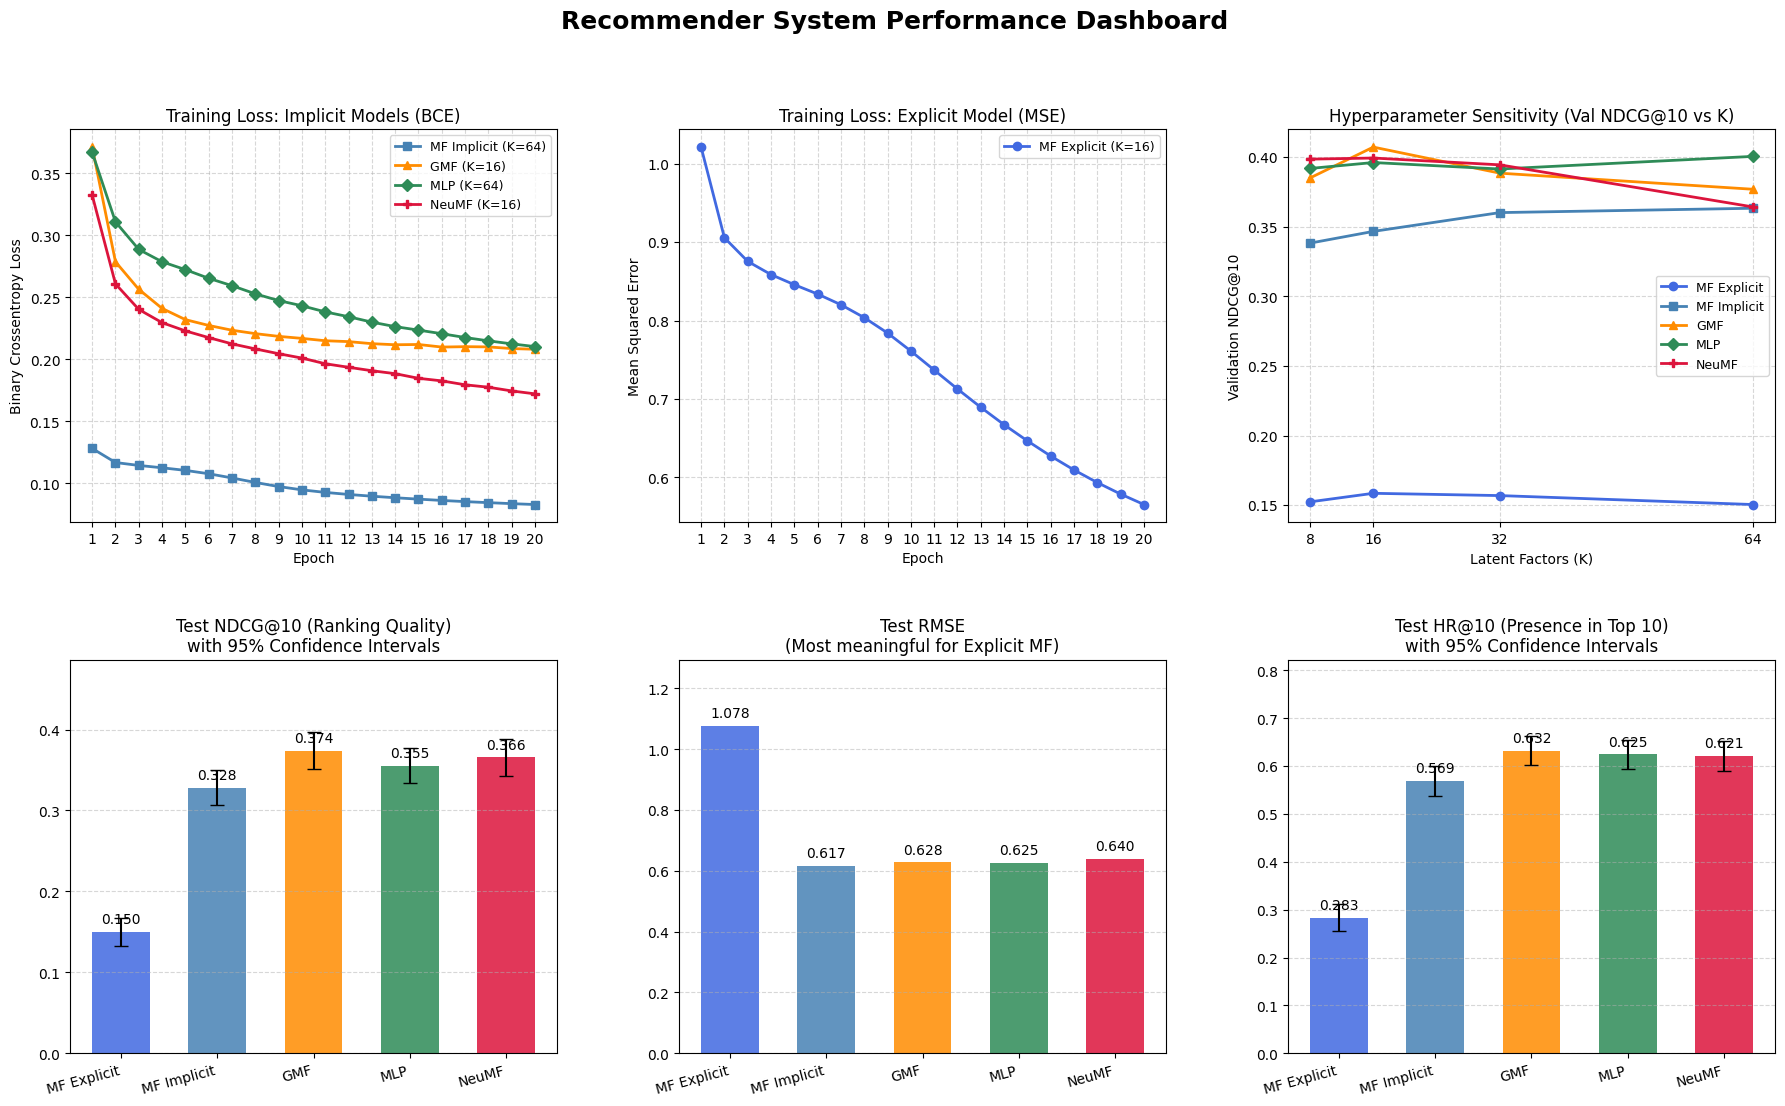

In [12]:

MODEL_COLORS = {
    "MF Explicit": "royalblue",
    "MF Implicit": "steelblue",
    "GMF":         "darkorange",
    "MLP":         "seagreen",
    "NeuMF":       "crimson",
}
MARKERS = {"MF Explicit": "o", "MF Implicit": "s", "GMF": "^", "MLP": "D", "NeuMF": "P"}

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.suptitle("Recommender System Performance Dashboard", fontsize=18, fontweight="bold")

# ── Plot 1: Implicit Models Training Loss ────────────────────────────────────
ax = axes[0, 0]
for name, res in all_results.items():
    if name != "MF Explicit":
        # Force flatten the array and explicitly define X-coordinates
        y = np.array(res["loss_curve"]).flatten()
        x = np.arange(1, len(y) + 1)
        ax.plot(x, y, label=f"{name} (K={res['best_k']})",
                color=MODEL_COLORS[name], marker=MARKERS[name], linewidth=2)

ax.set_title("Training Loss: Implicit Models (BCE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Crossentropy Loss")
if 'y' in locals(): ax.set_xticks(np.arange(1, len(y) + 1)) # Force integer X-ticks
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 2: Explicit Model Training Loss ─────────────────────────────────────
ax = axes[0, 1]
if "MF Explicit" in all_results:
    res = all_results["MF Explicit"]
    y = np.array(res["loss_curve"]).flatten()
    x = np.arange(1, len(y) + 1)
    ax.plot(x, y, label=f"MF Explicit (K={res['best_k']})",
            color=MODEL_COLORS["MF Explicit"], marker=MARKERS["MF Explicit"], linewidth=2)
    ax.set_xticks(np.arange(1, len(y) + 1)) # Force integer X-ticks

ax.set_title("Training Loss: Explicit Model (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 3: Validation NDCG@10 vs K ──────────────────────────────────────────
ax = axes[0, 2]
for name, res in all_results.items():
    ks = sorted(res["eval_k"].keys())
    y = [res["eval_k"][k] for k in ks]
    ax.plot(ks, y, label=name, color=MODEL_COLORS[name], marker=MARKERS[name], linewidth=2)
ax.set_title("Hyperparameter Sensitivity (Val NDCG@10 vs K)")
ax.set_xlabel("Latent Factors (K)")
ax.set_ylabel("Validation NDCG@10")
ax.set_xticks(K_VALUES)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# ── Plot 4: Test NDCG@10 with CIs ─────────────────────────────────────────────
ax = axes[1, 0]
names   = list(all_results.keys())
ndcgs   = [all_results[n]["NDCG@10"] for n in names]
ndcg_ci = [all_results[n].get("NDCG_CI", 0) for n in names] # Use .get to avoid errors
colors  = [MODEL_COLORS[n] for n in names]
x_pos   = np.arange(len(names))

# SINGLE bar call with yerr
bars = ax.bar(x_pos, ndcgs, yerr=ndcg_ci, capsize=5, color=colors, alpha=0.85, width=0.6)

ax.set_title("Test NDCG@10 (Ranking Quality)\nwith 95% Confidence Intervals")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(ndcgs + [0.1]) * 1.3) # Added padding for error bars
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

# ── Plot 5: Test RMSE ─────────────────────────────────────────────────────────
ax = axes[1, 1]
rmse_vals = [all_results[n]["RMSE"] for n in names]
bars = ax.bar(x_pos, rmse_vals, color=colors, alpha=0.85, width=0.6)
ax.set_title("Test RMSE\n(Most meaningful for Explicit MF)")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(rmse_vals + [0.1]) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)
for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

# ── Plot 6: Test HR@10 with CIs ───────────────────────────────────────────────
ax = axes[1, 2]
hrs   = [all_results[n]["HR@10"] for n in names]
hr_ci = [all_results[n].get("HR_CI", 0) for n in names]

# SINGLE bar call with yerr
bars = ax.bar(x_pos, hrs, yerr=hr_ci, capsize=5, color=colors, alpha=0.85, width=0.6)

ax.set_title("Test HR@10 (Presence in Top 10)\nwith 95% Confidence Intervals")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, max(hrs + [0.1]) * 1.3) # Added padding for error bars
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    ax.annotate(f"{bar.get_height():.3f}", xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=10)

plt.show()

In [13]:
def ci(data, confidence=0.95):

  # Perhaps use student-t because the standard deviation is point estimated
  #3.182446
  mean_of_data = np.mean(data)
  #ci_margin = 1.96 * (np.std(data) / np.sqrt(len(data)))
  ci_margin = 1.96 * (np.std(data) / np.sqrt(len(data)))
  return mean_of_data, ci_margin

#results_for_num_negatives: Dict[str, dict] = {}
#run expermients multiple times
NUMBER_OF_RUNS = 10
list_of_results_explicit_dic1 = []



#threading so faster so faster
"""
Not fair comparison MF implicit has fixed negaties for every run and keras re samples per psotivie every epoch dynamically unfair inlcude in discussion




with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {
      ex.submit(run_mf_experiment, f"Experiment {i+1}: Explicit MF (SVD)", training_split,valid_set, test_set,mode="explicit", num_users=num_users, num_items=num_items,) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic1.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['MF Explicit'] = temp


mean_d, margin = ci([d["HR@10"] for d in list_of_results_explicit_dic1 ])
print(mean_d, margin)
list_of_results_explicit_dic2 = []
temp_implicit = results_for_num_negatives.get('MF Implicit', {})

with ThreadPoolExecutor(max_workers=NUMBER_OF_RUNS) as ex:
  futures = {

      ex.submit(run_mf_experiment, f"Experiment {i+1}: Implicit MF (SVD)", add_negative_samples(training_split, num_movies, (i+1)),valid_set_implicit, test_set_implicit,mode="implicit", num_users=num_users, num_items=num_items,) : i for i in range(NUMBER_OF_RUNS)
  }
  temp = {}
  for future in as_completed(futures):
    i = futures[future]
    list_of_results_explicit_dic2.append(future.result())
    print(f"Finished run {i}")
    temp[i] = future.result()
    results_for_num_negatives['MF Implicit'] = temp
"""

# Run Implicit mf

# Grab the Implicit MF results if they exist
temp_implicit = results_for_num_negatives.get('MF Implicit', {})

print("\nStarting Implicit MF Runs...")
for i in range(NUMBER_OF_RUNS):
    # THE MAGIC LOGIC: Skip if already done
    if i in temp_implicit:
        print(f"  -> Skipping Implicit MF Run {i+1}/{NUMBER_OF_RUNS}: Already completed!")
        continue

    print(f"\n--- Implicit MF Run {i+1}/{NUMBER_OF_RUNS} ---")

    # Notice we use add_negative_samples(training_split, num_movies, (i+1)) here as you originally had
    result = run_mf_experiment(
        f"Experiment {i+1}: Implicit MF (SVD)",
        add_negative_samples(training_split, num_movies, (i+1)),
        valid_set_implicit,
        test_set_implicit,
        mode="implicit",
        num_users=num_users,
        num_items=num_items
    )

    # Save the result into our dictionary
    temp_implicit[i] = result
    results_for_num_negatives['MF Implicit'] = temp_implicit

    # Auto-save to Drive immediately
    with open(save_path, 'wb') as f:
        pickle.dump(results_for_num_negatives, f)
    print(f"Implicit MF Run {i+1} securely saved to Drive!")




# Run GMF Sequentially
list_of_results_explicit_dic3 = []
temp_gmf = results_for_num_negatives.get('GMF', {})

print("\nStarting GMF Runs...")
for i in range(NUMBER_OF_RUNS):
    if i in temp_gmf:
        print(f"  -> Skipping GMF Run {i+1}/{NUMBER_OF_RUNS}: Already completed!")
        continue
    print(f"\n--- GMF Run {i+1}/{NUMBER_OF_RUNS} ---")
    result = run_ncf_experiment(
        f"Experiment {i+1}: Generalised Matrix Factorisation (GMF)",
        "GMF",
        training_split,
        valid_set_implicit,
        test_set_implicit,
        num_users,
        num_items,
        i+1  # num_negatives increases with i
    )
    list_of_results_explicit_dic3.append(result)
    temp_gmf[i] = result
    results_for_num_negatives['GMF'] = temp_gmf

    with open(save_path, 'wb') as f:
        pickle.dump(results_for_num_negatives, f)
    print(f"GMF Run {i+1} securely saved to Drive!")



# Run MLP Sequentially
list_of_results_explicit_dic4 = []
temp_mlp = results_for_num_negatives.get('MLP', {})

print("\nStarting MLP Runs...")
for i in range(NUMBER_OF_RUNS):
    if i in temp_mlp:
        print(f"  -> Skipping GMF Run {i+1}/{NUMBER_OF_RUNS}: Already completed!")
        continue
    print(f"\n--- MLP Run {i+1}/{NUMBER_OF_RUNS} ---")
    result = run_ncf_experiment(
        f"Experiment {i+1}: MLP",
        "MLP",
        training_split,
        valid_set_implicit,
        test_set_implicit,
        num_users,
        num_items,
        i+1
    )
    list_of_results_explicit_dic4.append(result)
    temp_mlp[i] = result
    results_for_num_negatives['MLP'] = temp_mlp
    with open(save_path, 'wb') as f:
        pickle.dump(results_for_num_negatives, f)
    print(f"GMF Run {i+1} securely saved to Drive!")




# Run NeuMF Sequentially
list_of_results_explicit_dic5 = []
temp_neumf = results_for_num_negatives.get('NeuMF', {})

print("\nStarting NeuMF Runs...")
for i in range(NUMBER_OF_RUNS):
    if i in temp_neumf:
        print(f"  -> Skipping GMF Run {i+1}/{NUMBER_OF_RUNS}: Already completed!")
        continue
    print(f"\n--- NeuMF Run {i+1}/{NUMBER_OF_RUNS} ---")
    result = run_ncf_experiment(
        f"Experiment {i+1}: NeuMF",
        "NeuMF",
        training_split,
        valid_set_implicit,
        test_set_implicit,
        num_users,
        num_items,
        i+1
    )
    list_of_results_explicit_dic5.append(result)
    temp_neumf[i] = result
    results_for_num_negatives['NeuMF'] = temp_neumf
    with open(save_path, 'wb') as f:
        pickle.dump(results_for_num_negatives, f)
    print(f"GMF Run {i+1} securely saved to Drive!")





Starting Implicit MF Runs...
  -> Skipping Implicit MF Run 1/8: Already completed!
  -> Skipping Implicit MF Run 2/8: Already completed!
  -> Skipping Implicit MF Run 3/8: Already completed!
  -> Skipping Implicit MF Run 4/8: Already completed!
  -> Skipping Implicit MF Run 5/8: Already completed!
  -> Skipping Implicit MF Run 6/8: Already completed!
  -> Skipping Implicit MF Run 7/8: Already completed!
  -> Skipping Implicit MF Run 8/8: Already completed!

Starting GMF Runs...
  -> Skipping GMF Run 1/8: Already completed!
  -> Skipping GMF Run 2/8: Already completed!
  -> Skipping GMF Run 3/8: Already completed!
  -> Skipping GMF Run 4/8: Already completed!
  -> Skipping GMF Run 5/8: Already completed!
  -> Skipping GMF Run 6/8: Already completed!
  -> Skipping GMF Run 7/8: Already completed!
  -> Skipping GMF Run 8/8: Already completed!

Starting MLP Runs...
  -> Skipping GMF Run 1/8: Already completed!
  -> Skipping GMF Run 2/8: Already completed!
  -> Skipping GMF Run 3/8: Already

Tuning NeuMF:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


  NeuMF K=8 Epoch 1/20 | loss=0.2763 | val_NDCG@10=0.3701 (+/-0.0222) [18.3s]
  NeuMF K=8 Epoch 2/20 | loss=0.2289 | val_NDCG@10=0.3707 (+/-0.0219) [15.0s]
  NeuMF K=8 Epoch 3/20 | loss=0.2169 | val_NDCG@10=0.3727 (+/-0.0221) [15.4s]
  NeuMF K=8 Epoch 4/20 | loss=0.2102 | val_NDCG@10=0.3806 (+/-0.0225) [20.1s]
  NeuMF K=8 Epoch 5/20 | loss=0.2048 | val_NDCG@10=0.3965 (+/-0.0223) [15.2s]
  NeuMF K=8 Epoch 6/20 | loss=0.2001 | val_NDCG@10=0.3835 (+/-0.0220) [15.2s]
  NeuMF K=8 Epoch 7/20 | loss=0.1963 | val_NDCG@10=0.3950 (+/-0.0225) [14.6s]
  NeuMF K=8 Epoch 8/20 | loss=0.1924 | val_NDCG@10=0.3845 (+/-0.0218) [14.6s]
  NeuMF K=8 Epoch 9/20 | loss=0.1891 | val_NDCG@10=0.3951 (+/-0.0223) [14.4s]
  NeuMF K=8 Epoch 10/20 | loss=0.1861 | val_NDCG@10=0.3952 (+/-0.0227) [14.3s]
  NeuMF K=8 Epoch 11/20 | loss=0.1828 | val_NDCG@10=0.4057 (+/-0.0229) [15.0s]
  NeuMF K=8 Epoch 12/20 | loss=0.1798 | val_NDCG@10=0.3875 (+/-0.0222) [14.4s]
  NeuMF K=8 Epoch 13/20 | loss=0.1767 | val_NDCG@10=0.3944 (+

Tuning NeuMF:  25%|██▌       | 1/4 [05:02<15:07, 302.59s/it]

  NeuMF K=8 Epoch 20/20 | loss=0.1594 | val_NDCG@10=0.3806 (+/-0.0223) [14.3s]
  NeuMF K=16 Epoch 1/20 | loss=0.2724 | val_NDCG@10=0.3556 (+/-0.0220) [19.7s]
  NeuMF K=16 Epoch 2/20 | loss=0.2179 | val_NDCG@10=0.3925 (+/-0.0228) [15.0s]
  NeuMF K=16 Epoch 3/20 | loss=0.2025 | val_NDCG@10=0.3815 (+/-0.0226) [14.0s]
  NeuMF K=16 Epoch 4/20 | loss=0.1941 | val_NDCG@10=0.3940 (+/-0.0226) [13.5s]
  NeuMF K=16 Epoch 5/20 | loss=0.1884 | val_NDCG@10=0.3877 (+/-0.0223) [14.3s]
  NeuMF K=16 Epoch 6/20 | loss=0.1832 | val_NDCG@10=0.3923 (+/-0.0223) [14.5s]
  NeuMF K=16 Epoch 7/20 | loss=0.1790 | val_NDCG@10=0.3894 (+/-0.0224) [15.5s]
  NeuMF K=16 Epoch 8/20 | loss=0.1754 | val_NDCG@10=0.3924 (+/-0.0221) [14.5s]
  NeuMF K=16 Epoch 9/20 | loss=0.1720 | val_NDCG@10=0.3892 (+/-0.0216) [13.7s]
  NeuMF K=16 Epoch 10/20 | loss=0.1689 | val_NDCG@10=0.4021 (+/-0.0226) [14.9s]
  NeuMF K=16 Epoch 11/20 | loss=0.1655 | val_NDCG@10=0.3929 (+/-0.0223) [15.1s]
  NeuMF K=16 Epoch 12/20 | loss=0.1625 | val_NDCG@

...

Tuning NeuMF:  75%|███████▌  | 3/4 [19:29<06:29, 389.51s/it]

  NeuMF K=32 Epoch 20/20 | loss=0.0958 | val_NDCG@10=0.3510 (+/-0.0224) [18.3s]
  NeuMF K=64 Epoch 1/20 | loss=0.2287 | val_NDCG@10=0.3707 (+/-0.0220) [25.1s]
  NeuMF K=64 Epoch 2/20 | loss=0.1663 | val_NDCG@10=0.3760 (+/-0.0223) [20.6s]
  NeuMF K=64 Epoch 3/20 | loss=0.1345 | val_NDCG@10=0.3631 (+/-0.0222) [29.0s]
  NeuMF K=64 Epoch 4/20 | loss=0.1161 | val_NDCG@10=0.3410 (+/-0.0212) [29.2s]
  NeuMF K=64 Epoch 5/20 | loss=0.1041 | val_NDCG@10=0.3486 (+/-0.0217) [29.2s]
  NeuMF K=64 Epoch 6/20 | loss=0.0957 | val_NDCG@10=0.3287 (+/-0.0219) [22.1s]
  NeuMF K=64 Epoch 7/20 | loss=0.0891 | val_NDCG@10=0.3369 (+/-0.0217) [20.4s]
  NeuMF K=64 Epoch 8/20 | loss=0.0840 | val_NDCG@10=0.3259 (+/-0.0216) [28.7s]
  NeuMF K=64 Epoch 9/20 | loss=0.0789 | val_NDCG@10=0.3296 (+/-0.0222) [22.3s]
  NeuMF K=64 Epoch 10/20 | loss=0.0748 | val_NDCG@10=0.3325 (+/-0.0217) [21.1s]
  NeuMF K=64 Epoch 11/20 | loss=0.0707 | val_NDCG@10=0.3149 (+/-0.0212) [23.8s]
  NeuMF K=64 Epoch 12/20 | loss=0.0677 | val_NDCG

Tuning NeuMF: 100%|██████████| 4/4 [27:37<00:00, 414.36s/it]

  NeuMF K=64 Epoch 20/20 | loss=0.0483 | val_NDCG@10=0.3098 (+/-0.0219) [22.0s]
Best K=16 | Best Val NDCG@10=0.4020


  RMSE=0.7342  NDCG@10=0.3577  HR@10=0.6448
GMF Run 8 securely saved to Drive!


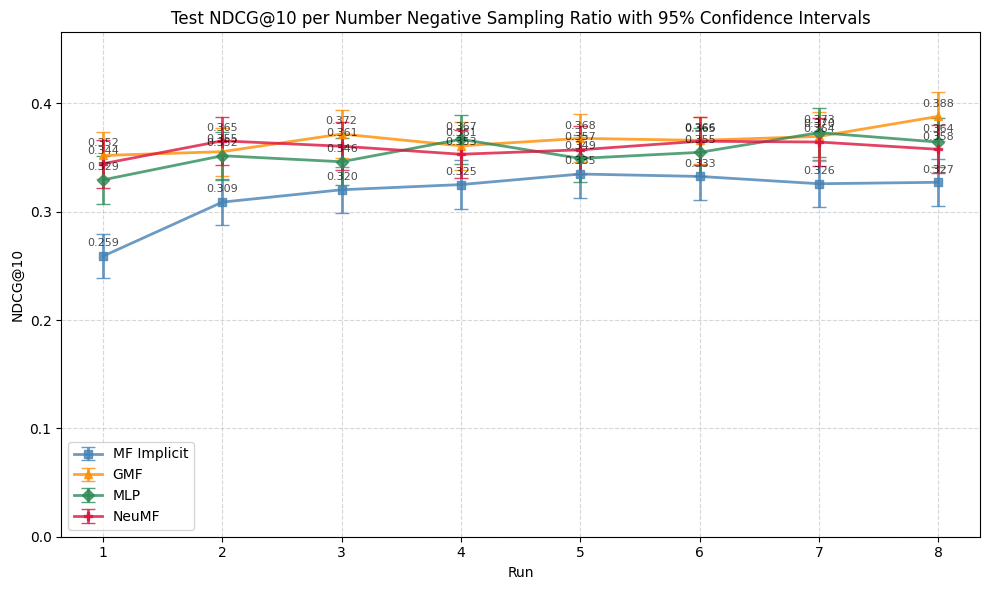

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Setup X-axis (1-8)
xs = list(range(1, NUMBER_OF_RUNS+1))

# Assuming MODEL_COLORS and MARKERS are defined elsewhere in your code
# If not, you can replace them with strings like 'blue' and 'o'

for name, res in results_for_num_negatives.items():
    # Extract Y values (NDCG@10)
    y = [res[i]["NDCG@10"] for i in range(NUMBER_OF_RUNS)]

    # Extract CI values (Error bars)
    # Ensure your data structure has "NDCG_CI" for each point in the range
    yerr = [res[i].get("NDCG_CI", 0) for i in range(NUMBER_OF_RUNS)]

    # Use errorbar instead of plot
    ax.errorbar(
        xs,
        y,
        yerr=yerr,
        label=name,
        #color=MODEL_COLORS.get(name, 'black'),
        color=MODEL_COLORS[name],
        #marker=MARKERS.get(name, 'o'),
        marker=MARKERS[name],
        linewidth=2,
        capsize=5,          # Length of the error bar caps
        linestyle='-',      # Keeps the line connecting the dots
        alpha=0.8
    )

# Formatting
ax.set_title("Test NDCG@10 per Number Negative Sampling Ratio with 95% Confidence Intervals")
ax.set_xlabel("Run")
ax.set_ylabel("NDCG@10")
ax.set_xticks(xs)

# Optional: Adding value labels above the dots
for name, res in results_for_num_negatives.items():
    for i, val in enumerate([res[j]["NDCG@10"] for j in range(NUMBER_OF_RUNS)]):
        ax.annotate(f"{val:.3f}",
                    xy=(xs[i], val),
                    xytext=(0, 7),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                    alpha=0.7)

ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

# Adjust Y-limit to make room for error bars
all_y = [res[i]["NDCG@10"] for res in results_for_num_negatives.values() for i in range(NUMBER_OF_RUNS)]
if all_y:
    ax.set_ylim(0, max(all_y) * 1.2)

plt.tight_layout()
plt.show()

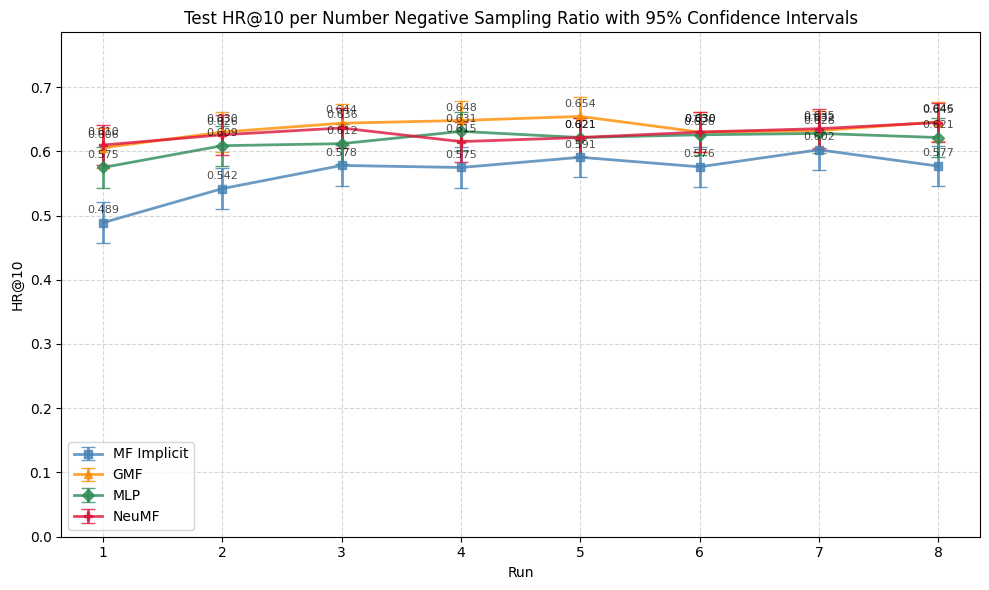

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Setup X-axis (1-8)
xs = list(range(1, NUMBER_OF_RUNS+1))

# Assuming MODEL_COLORS and MARKERS are defined elsewhere in your code
# If not, you can replace them with strings like 'blue' and 'o'

for name, res in results_for_num_negatives.items():
    # Extract Y values (HR@10)
    y = [res[i]["HR@10"] for i in range(NUMBER_OF_RUNS)]

    # Extract CI values (Error bars)
    # Ensure your data structure has "HR_CI" for each point in the range
    yerr = [res[i].get("HR_CI", 0) for i in range(NUMBER_OF_RUNS)]

    # Use errorbar instead of plot
    ax.errorbar(
        xs,
        y,
        yerr=yerr,
        label=name,
        color=MODEL_COLORS.get(name, 'black'),
        marker=MARKERS.get(name, 'o'),
        linewidth=2,
        capsize=5,          # Length of the error bar caps
        linestyle='-',      # Keeps the line connecting the dots
        alpha=0.8
    )

# Formatting
ax.set_title("Test HR@10 per Number Negative Sampling Ratio with 95% Confidence Intervals")
ax.set_xlabel("Run")
ax.set_ylabel("HR@10")
ax.set_xticks(xs)

# Optional: Adding value labels above the dots
for name, res in results_for_num_negatives.items():
    for i, val in enumerate([res[j]["HR@10"] for j in range(NUMBER_OF_RUNS)]):
        ax.annotate(f"{val:.3f}",
                    xy=(xs[i], val),
                    xytext=(0, 7),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                    alpha=0.7)

ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

# Adjust Y-limit to make room for error bars
all_y = [res[i]["HR@10"] for res in results_for_num_negatives.values() for i in range(NUMBER_OF_RUNS)]
if all_y:
    ax.set_ylim(0, max(all_y) * 1.2)

plt.tight_layout()
plt.show()

In [16]:
def bootstrap_ci(scores, n_boot=1000, alpha=0.95):
    scores = np.array(scores)
    n = len(scores)
    boot_means = np.array([
        np.mean(rng.choice(scores, size=n, replace=True))
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_means, (1-alpha)/2 * 100)
    hi = np.percentile(boot_means, (1+alpha)/2 * 100)
    return float(np.mean(scores)), lo, hi

rng = np.random.default_rng(seed=42)